# Histology First POC

This notebook is the first version of a project I could show Prof. Marina Eckermann.

I kept it narrow on purpose. One modality first. Histology tiles.

That gives me something I can actually run, explain, defend, and later extend toward cross-modal analysis with CT and spatial transcriptomics.

## Notebook plan

- inspect the dataset properly
- build a classical feature baseline
- train a small CNN baseline
- export embeddings and metadata for later cross-modal matching


## Dataset choice

I use **Colorectal Histology MNIST** from Kaggle.

Why I picked it:

- 5,000 histology tiles, so it is small enough for a quick proof of concept
- 8 tissue classes, so it is not a toy binary problem
- the visual texture differences are meaningful, which makes feature extraction and model comparison worth doing
- it is easy to explain in an interview without pretending it is already a full CT plus transcriptomics dataset


In [ ]:
# Core imports.
# I keep the stack eadable on purpose.

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import shannon_entropy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
# Reproducibility.
# Not magic. Just enough to stop the notebook from drifting every time I re-run it.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)


Running on: cpu


In [8]:
# Update this path after downloading the Kaggle dataset.
# I keep it explicit because hidden paths are annoying when a notebook moves from one machine to another.

DATA_DIR = Path(r"C:\Users\nosai\Downloads\histology_first_poc\data\colorectal-histology-mnist\Kather_texture_2016_image_tiles_5000")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    print("Dataset folder not found.")
    print("Download the dataset from Kaggle and place it under:")
    print(DATA_DIR.resolve())
else:
    print("Dataset folder found:", DATA_DIR.resolve())


Dataset folder found: C:\Users\nosai\Downloads\histology_first_poc\data\colorectal-histology-mnist\Kather_texture_2016_image_tiles_5000


In [9]:
# Read the image paths into a tidy table.
# I want one row per tile, with the label attached from the folder name.

records = []

if DATA_DIR.exists():
    for class_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
                records.append({"path": str(img_path), "label": class_name})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 5000


,path,label
0,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR
1,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR
2,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR
3,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR
4,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR


In [10]:
# Quick class count check.
# I always do this early. If the labels are broken, nothing later matters.

if len(df) > 0:
    display(df["label"].value_counts().to_frame("count"))


,count
label,
01_TUMOR,625
02_STROMA,625
03_COMPLEX,625
04_LYMPHO,625
05_DEBRIS,625
06_MUCOSA,625
07_ADIPOSE,625
08_EMPTY,625


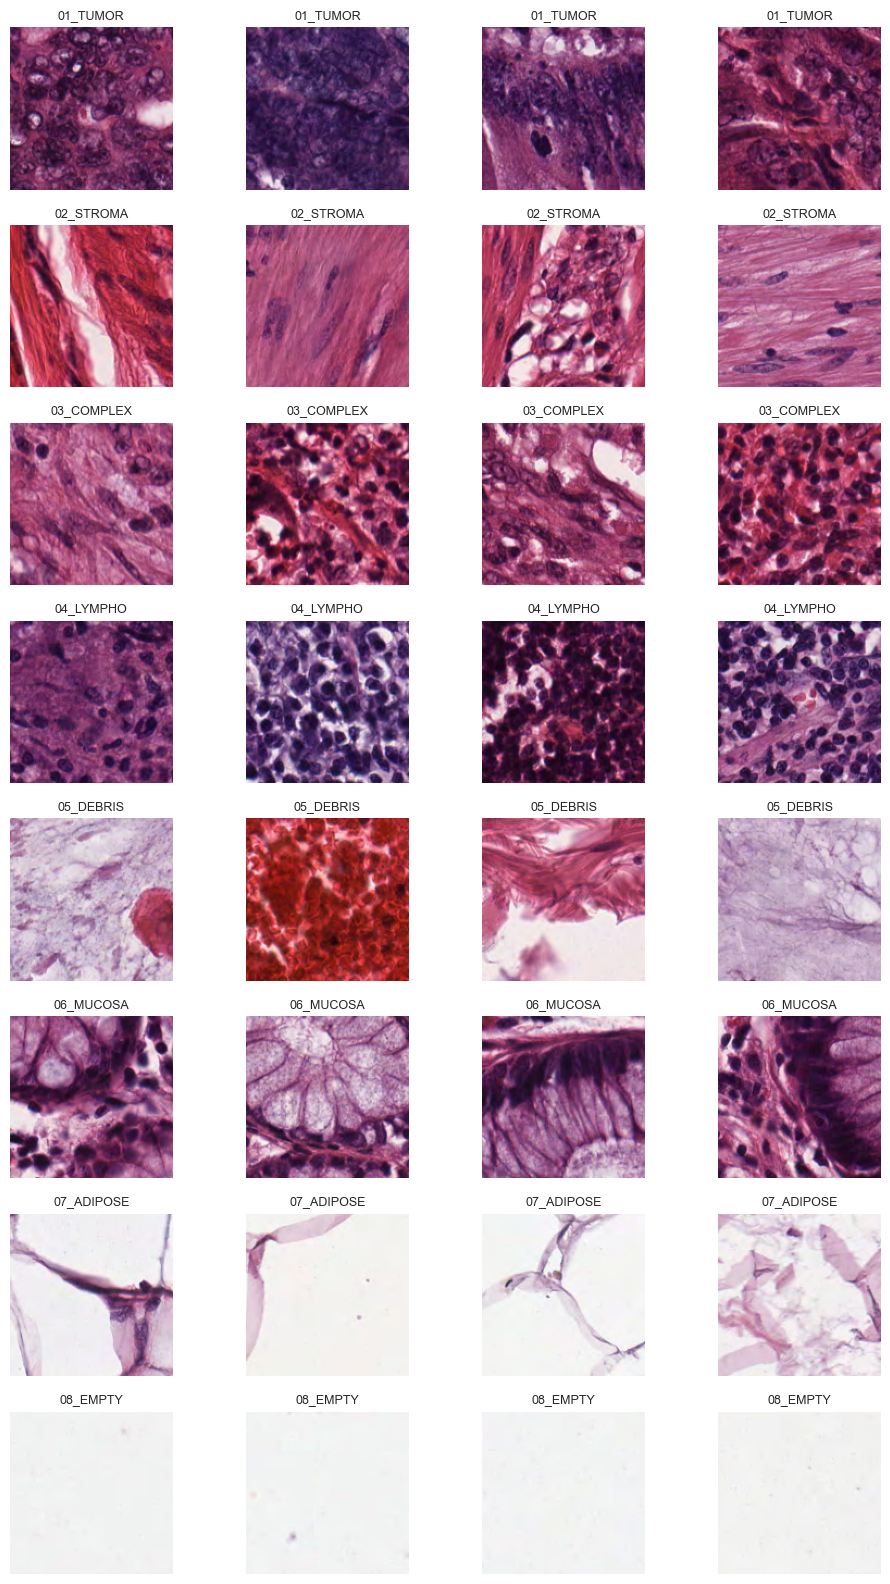

In [11]:
# Show a few sample tiles.
# This gives a fast sanity check and also makes the notebook easier to talk through.

if len(df) > 0:
    sample_df = df.groupby("label", group_keys=False).head(4)
    fig, axes = plt.subplots(len(sample_df["label"].unique()), 4, figsize=(10, 16))
    axes = np.array(axes).reshape(-1, 4)

    for row_idx, (label, group) in enumerate(sample_df.groupby("label")):
        for col_idx, (_, row) in enumerate(group.iterrows()):
            img = Image.open(row["path"]).convert("RGB")
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(label, fontsize=9)
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


## Classical baseline with colour and texture features

I start with a classical baseline for one simple reason.

If a deep model wins, I want to know what it beat. If the classical model is already strong, that tells me something about the data. Texture-heavy histology can behave like that.


In [12]:
# Handcrafted feature extractor.
# I keep this feature set compact enough to explain:
# - RGB means and standard deviations
# - grayscale entropy
# - simple Local Binary Pattern histogram
# - GLCM texture properties
#
# This is not meant to be fancy. It is meant to be legible.

def extract_handcrafted_features(image_path, lbp_points=8, lbp_radius=1):
    img = Image.open(image_path).convert("RGB")
    arr = np.array(img).astype(np.float32) / 255.0

    rgb_mean = arr.mean(axis=(0, 1))
    rgb_std = arr.std(axis=(0, 1))

    gray = rgb2gray(arr)
    gray_uint8 = (gray * 255).astype(np.uint8)

    entropy = shannon_entropy(gray_uint8)

    lbp = local_binary_pattern(gray_uint8, P=lbp_points, R=lbp_radius, method="uniform")
    n_bins = lbp_points + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    glcm = graycomatrix(
        gray_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    dissimilarity = graycoprops(glcm, "dissimilarity")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]
    asm = graycoprops(glcm, "ASM")[0, 0]

    features = np.concatenate([
        rgb_mean,
        rgb_std,
        np.array([entropy, contrast, dissimilarity, homogeneity, energy, correlation, asm]),
        lbp_hist
    ])

    return features


In [13]:
# Build the feature matrix.
# This takes a bit of time, but not a silly amount on this dataset.

if len(df) > 0:
    X_hand = []
    for p in tqdm(df["path"], desc="Extracting handcrafted features"):
        X_hand.append(extract_handcrafted_features(p))
    X_hand = np.vstack(X_hand)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])

    print("Handcrafted feature matrix shape:", X_hand.shape)
    print("Number of classes:", len(label_encoder.classes_))


Extracting handcrafted features:   0%|          | 0/5000 [00:00<?, ?it/s]

Handcrafted feature matrix shape: (5000, 23)
Number of classes: 8


In [14]:
# Train and test split.
# Stratified split because histology class balance matters, and I do not want a lopsided test set by accident.

if len(df) > 0:
    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X_hand, y, df, test_size=0.2, random_state=SEED, stratify=y
    )

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))


Train size: 4000
Test size: 1000


In [16]:
# Two small baselines:
# 1. Logistic Regression
# 2. Random Forest
#
# Logistic Regression gives me a linear baseline.
# Random Forest gives me a cheap nonlinear check.

if len(df) > 0:
    logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000))
])

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1
    )

    logreg.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    pred_logreg = logreg.predict(X_test)
    pred_rf = rf.predict(X_test)

    print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_logreg), 4))
    print("Random Forest accuracy:", round(accuracy_score(y_test, pred_rf), 4))


Logistic Regression accuracy: 0.876
Random Forest accuracy: 0.897


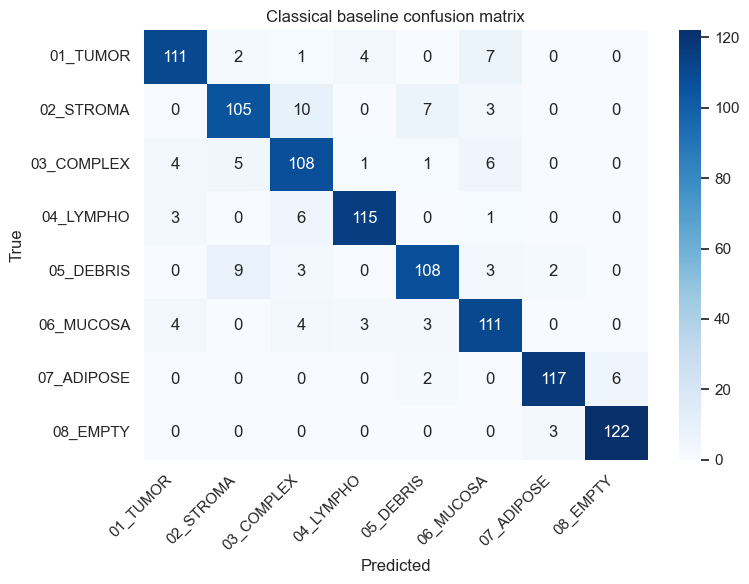

              precision    recall  f1-score   support

    01_TUMOR       0.91      0.89      0.90       125
   02_STROMA       0.87      0.84      0.85       125
  03_COMPLEX       0.82      0.86      0.84       125
   04_LYMPHO       0.93      0.92      0.93       125
   05_DEBRIS       0.89      0.86      0.88       125
   06_MUCOSA       0.85      0.89      0.87       125
  07_ADIPOSE       0.96      0.94      0.95       125
    08_EMPTY       0.95      0.98      0.96       125

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [17]:
# Confusion matrix for the stronger classical model.

if len(df) > 0:
    best_pred = pred_rf if accuracy_score(y_test, pred_rf) >= accuracy_score(y_test, pred_logreg) else pred_logreg
    cm = confusion_matrix(y_test, best_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title("Classical baseline confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))


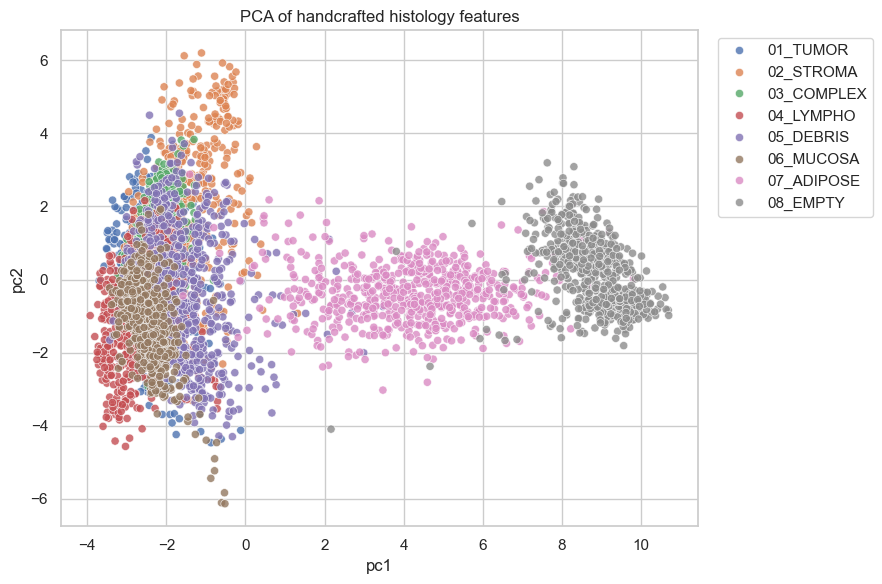

In [18]:
# PCA view of handcrafted features.
# This is not for publication. It is for intuition.

if len(df) > 0:
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X_hand))

    plot_df = pd.DataFrame({
        "pc1": X_pca[:, 0],
        "pc2": X_pca[:, 1],
        "label": df["label"].values
    })

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="label", s=35, alpha=0.8)
    plt.title("PCA of handcrafted histology features")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Small CNN baseline

Now the deep baseline.

I keep the network small enough that I can explain.


In [20]:
# Torch dataset and transforms.
# I resize to 128x128 to keep memory and training time sane.

train_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

class HistologyDataset(Dataset):
    def __init__(self, frame, label_encoder, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = self.label_encoder.transform([row["label"]])[0]

        if self.transform is not None:
            image = self.transform(image)

        return image, label, row["path"]

if len(df) > 0:
    train_dataset = HistologyDataset(df_train, label_encoder, transform=train_tfms)
    test_dataset = HistologyDataset(df_test, label_encoder, transform=test_tfms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)


In [21]:
# Small CNN.
# I keep an embedding layer before the final classifier because I want to export those features later.

class SmallHistologyCNN(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.embedding = nn.Linear(128, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        emb = self.embedding(x)
        logits = self.classifier(torch.relu(emb))

        if return_embedding:
            return logits, emb
        return logits

if len(df) > 0:
    model = SmallHistologyCNN(num_classes=len(label_encoder.classes_)).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

    print(model)


SmallHistologyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (embedding): Linear(in_features=128, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=8, bias=True)
)


In [24]:
# Training loop.
# I keep it plain. No trainer wrappers.

def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        logits = model(images)
        labels = labels.long()  # force correct dtype
        loss = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        labels = labels.long()  # force correct dtype
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


In [25]:
# Train for a few epochs.
# This is a proof of concept, not a leaderboard run.

history = []

if len(df) > 0:
    EPOCHS = 6

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, DEVICE)
        val_loss, val_acc, val_preds, val_labels = evaluate(model, test_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
        )

    history_df = pd.DataFrame(history)
    display(history_df)


Epoch 01 | train loss 1.2996 | train acc 0.4195 | val loss 0.9737 | val acc 0.5580
Epoch 02 | train loss 0.9641 | train acc 0.5807 | val loss 0.8137 | val acc 0.7090
Epoch 03 | train loss 0.8875 | train acc 0.6200 | val loss 0.8850 | val acc 0.5950
Epoch 04 | train loss 0.8128 | train acc 0.6603 | val loss 0.7749 | val acc 0.6670
Epoch 05 | train loss 0.7115 | train acc 0.7085 | val loss 0.6890 | val acc 0.7050
Epoch 06 | train loss 0.7350 | train acc 0.6995 | val loss 0.7346 | val acc 0.6980


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.299550,0.41950,0.973682,0.558
1,2,0.964115,0.58075,0.813708,0.709
2,3,0.887511,0.62000,0.884963,0.595
3,4,0.812769,0.66025,0.774920,0.667
4,5,0.711536,0.70850,0.689011,0.705
5,6,0.735029,0.69950,0.734566,0.698


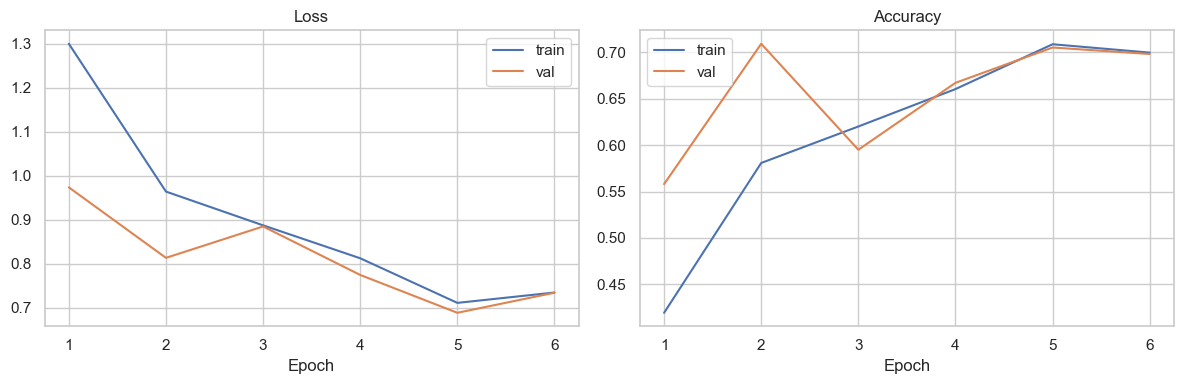

In [26]:
# Plot training history.

if len(df) > 0 and len(history) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


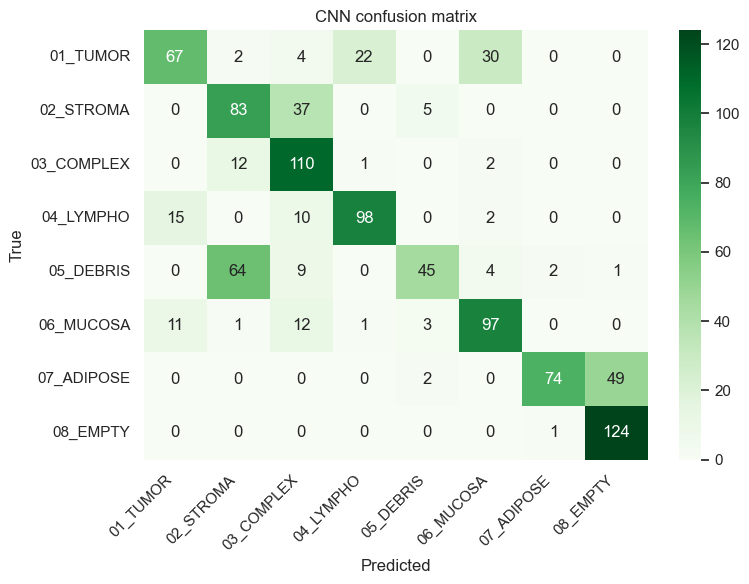

              precision    recall  f1-score   support

    01_TUMOR       0.72      0.54      0.61       125
   02_STROMA       0.51      0.66      0.58       125
  03_COMPLEX       0.60      0.88      0.72       125
   04_LYMPHO       0.80      0.78      0.79       125
   05_DEBRIS       0.82      0.36      0.50       125
   06_MUCOSA       0.72      0.78      0.75       125
  07_ADIPOSE       0.96      0.59      0.73       125
    08_EMPTY       0.71      0.99      0.83       125

    accuracy                           0.70      1000
   macro avg       0.73      0.70      0.69      1000
weighted avg       0.73      0.70      0.69      1000



In [27]:
# CNN confusion matrix.

if len(df) > 0:
    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title("CNN confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(classification_report(val_labels, val_preds, target_names=label_encoder.classes_))


## Export embeddings for later cross-modal work

This part is the point.

I do not just want a classifier. I want a table of learned image features that I can later join with sample metadata, CT-derived features, or transcriptomic features.


In [28]:
@torch.no_grad()
def extract_embeddings(model, loader, device, label_encoder):
    model.eval()
    rows = []

    for images, labels, paths in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(device)
        logits, emb = model(images, return_embedding=True)
        preds = logits.argmax(dim=1).cpu().numpy()
        emb = emb.cpu().numpy()
        labels = labels.numpy()

        for i in range(len(paths)):
            row = {
                "path": paths[i],
                "true_label": label_encoder.inverse_transform([labels[i]])[0],
                "pred_label": label_encoder.inverse_transform([preds[i]])[0],
            }
            for j, value in enumerate(emb[i]):
                row[f"emb_{j:03d}"] = float(value)
            rows.append(row)

    return pd.DataFrame(rows)

if len(df) > 0:
    full_dataset = HistologyDataset(df, label_encoder, transform=test_tfms)
    full_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=0)

    embeddings_df = extract_embeddings(model, full_loader, DEVICE, label_encoder)
    embeddings_path = OUTPUT_DIR / "histology_tile_embeddings.csv"
    embeddings_df.to_csv(embeddings_path, index=False)

    print("Saved embeddings to:", embeddings_path.resolve())
    display(embeddings_df.head())


Extracting embeddings:   0%|          | 0/157 [00:00<?, ?it/s]

Saved embeddings to: C:\Users\nosai\Downloads\outputs\histology_tile_embeddings.csv


,path,true_label,pred_label,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR,01_TUMOR,12.948834,-2.259423,-4.933290,-0.950893,0.292133,-15.409527,11.812013,...,-4.628257,-2.590094,2.220068,-1.663960,-6.166270,-14.502205,-17.375507,-5.914731,8.692250,12.939478
1,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR,04_LYMPHO,22.084801,-4.599947,-4.447268,-8.933721,-3.963333,-18.076164,14.089428,...,-7.443708,-3.316809,4.998126,-1.193125,-5.058663,-17.589609,-16.951818,-8.465769,8.338056,25.781973
2,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR,01_TUMOR,13.416512,-2.710722,-5.305374,-1.636768,0.487905,-15.675755,12.172718,...,-4.933611,-2.453327,2.562208,-1.742297,-5.939192,-14.431384,-17.444090,-6.066355,8.867546,13.789979
3,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR,01_TUMOR,10.917599,-1.595702,-5.157312,1.111652,0.814016,-15.064405,11.445140,...,-4.017137,-2.483821,1.446262,-1.670502,-6.492441,-14.058936,-17.733208,-5.331854,9.272679,10.241960
4,C:\Users\nosai\Downloads\histology_first_poc\d...,01_TUMOR,01_TUMOR,14.211540,-2.680392,-4.722987,-2.051666,0.481634,-16.054913,12.258511,...,-5.101567,-2.657940,2.364714,-1.810307,-6.213598,-15.177633,-17.735889,-6.503249,8.240527,14.548779


In [29]:
# Save the CNN weights too.

if len(df) > 0:
    model_path = OUTPUT_DIR / "small_histology_cnn.pt"
    torch.save(model.state_dict(), model_path)
    print("Saved model weights to:", model_path.resolve())


Saved model weights to: C:\Users\nosai\Downloads\outputs\small_histology_cnn.pt


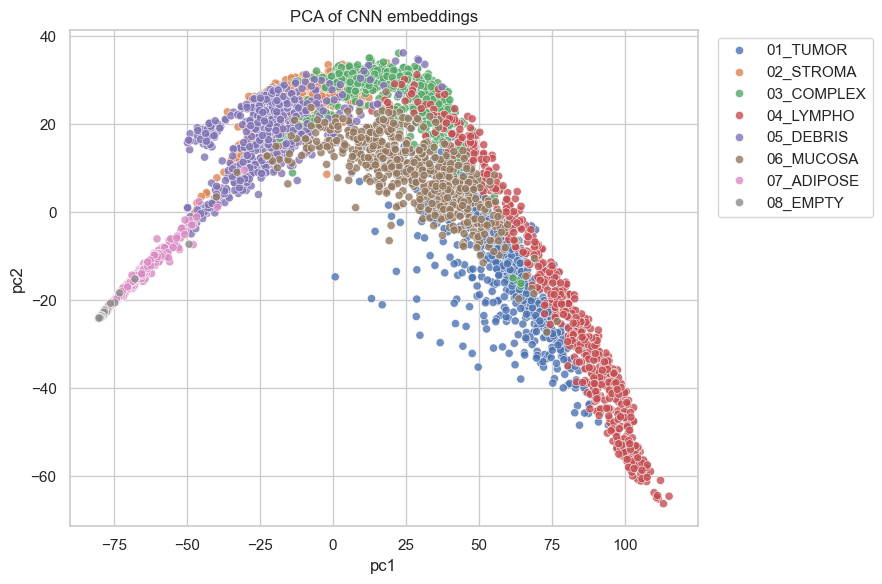

In [30]:
# Small visual check of embedding space with PCA.

if len(df) > 0:
    emb_cols = [c for c in embeddings_df.columns if c.startswith("emb_")]
    pca_emb = PCA(n_components=2, random_state=SEED)
    emb_2d = pca_emb.fit_transform(embeddings_df[emb_cols].values)

    plot_emb = embeddings_df[["true_label"]].copy()
    plot_emb["pc1"] = emb_2d[:, 0]
    plot_emb["pc2"] = emb_2d[:, 1]

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_emb, x="pc1", y="pc2", hue="true_label", s=35, alpha=0.8)
    plt.title("PCA of CNN embeddings")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## What I would say about this POC

I would frame it like this:

- I started with histology only because I wanted a fast proof of concept I could actually defend.
- I compared a classical texture baseline and a small CNN, so I can talk about what the deep model is adding.
- I export per-tile embeddings and metadata, which is the part I would later align with CT regions or spatial transcriptomic spots.
- So even though this first notebook is unimodal, the structure already points toward the cross-modal analysis question.
